In [1]:
#import neccessary libraries
import numpy as np
import pandas as pd
import csv
import scipy.stats

#read position info info file as 
#set root file name
root_file = 'Gamma-E25-n1000-part9'

#read cluster distribution csv as a dataframe and get noise level that minimizes cluster number
df = pd.read_csv('cluster-noise-distribution_'+root_file+'.csv')
noise = df['noise'][df['n_clusters_mean'].idxmin()]

n_events=1000
cluster_n = 1
df_5v_res_n = pd.read_csv('particle-info_'+root_file+'_noise-'+str(noise)+'_event'+str(n_events)+'_signal'+str(cluster_n)+'.csv')
df_5v_res_n

In [37]:
#read ALL files into single dataframe
import glob

#read cluster distribution csv as a dataframe and get noise level that minimizes cluster number
root_file = 'Gamma-E200-n1000-part3'
df = pd.read_csv('cluster-noise-distribution_'+root_file+'.csv')
noise = df['noise'][df['n_clusters_mean'].idxmin()]

n_events=1000
cluster_n = 1

energy = 200
all_files = glob.glob('particle-info_Gamma-E'+str(energy)+'-n1000-part*_noise-'+str(noise)+'_event'+str(n_events)+'_signal'+str(cluster_n)+'.csv')
#all_files = glob.glob('/store/user/dgaytanv/particle-info/Gamma/particle-info_Gamma-E200-n1000-part1_noise-0.15_event1000_signal1.csv')
#all_files
df_5v_res_n = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)
df_5v_res_n

,event_n,x,y,z,e,t,clusterindex,cluster_count,sum(E_hit),RecHitHGC_x,RecHitHGC_y,RecHitHGC_z,GenVtx_x,GenVtx_y,GenVtx_z,GenHit_x,GenHit_y,Diff_x,Diff_y
0,0,87.58,-41.70,323.08,0.041,-1.000000,175,1,196.925,87.58,-41.70,323.08,89.31,-38.84,320.94,89.905511,-39.098982,2.325511,2.601018
1,0,89.67,-39.30,323.08,0.185,5.172852,175,1,196.925,89.67,-39.30,323.08,89.31,-38.84,320.94,89.905511,-39.098982,0.235511,0.201018
2,0,95.96,-61.01,323.08,0.012,-1.000000,175,1,196.925,95.96,-61.01,323.08,89.31,-38.84,320.94,89.905511,-39.098982,-6.054489,21.911018
3,0,85.50,-46.51,325.04,0.098,6.075684,175,1,196.925,85.50,-46.51,325.04,89.31,-38.84,320.94,90.450933,-39.336180,4.950933,7.173820
4,0,86.54,-47.11,325.04,0.029,-1.000000,175,1,196.925,86.54,-47.11,325.04,89.31,-38.84,320.94,90.450933,-39.336180,3.910933,7.773820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10461344,999,-78.87,65.27,367.70,0.044,-1.000000,51,1,197.961,-78.87,65.27,367.70,-63.81,58.84,320.50,-73.207292,67.505360,5.662708,2.235360
10461345,999,-77.83,64.67,367.70,0.091,-1.000000,51,1,197.961,-77.83,64.67,367.70,-63.81,58.84,320.50,-73.207292,67.505360,4.622708,2.835360
10461346,999,-73.61,75.56,367.70,0.257,5.124023,51,1,197.961,-73.61,75.56,367.70,-63.81,58.84,320.50,-73.207292,67.505360,0.402708,-8.054640
10461347,999,-70.49,61.64,373.15,0.120,-1.000000,51,1,197.961,-70.49,61.64,373.15,-63.81,58.84,320.50,-74.292360,68.505916,-3.802360,6.865916


df_5v_res_n = pd.concat([df_5v_res_1, df_5v_res_2, df_5v_res_3, df_5v_res_4, df_5v_res_5, df_5v_res_6, df_5v_res_7, df_5v_res_8, df_5v_res_9, df_5v_res_10], ignore_index=True)

In [38]:
## save dataframe to csv
#df_5v_res_n.to_csv('particle-info_Gamma-E25-n1000-total_noise-'+str(noise)+'_event'+str(n_events)+'_signal'+str(cluster_n)+'.csv', index=False)

In [39]:
#filter all events with negative time values
df_5v_res_filter = df_5v_res_n
df_5v_res_filter.drop(df_5v_res_filter[df_5v_res_filter.t <= -1].index, inplace = True)
df_5v_res_filter = df_5v_res_filter.reset_index(drop=True)
df_5v_res_filter

,event_n,x,y,z,e,t,clusterindex,cluster_count,sum(E_hit),RecHitHGC_x,RecHitHGC_y,RecHitHGC_z,GenVtx_x,GenVtx_y,GenVtx_z,GenHit_x,GenHit_y,Diff_x,Diff_y
0,0,89.67,-39.30,323.08,0.185,5.172852,175,1,196.925,89.67,-39.30,323.08,89.31,-38.84,320.94,89.905511,-39.098982,0.235511,0.201018
1,0,85.50,-46.51,325.04,0.098,6.075684,175,1,196.925,85.50,-46.51,325.04,89.31,-38.84,320.94,90.450933,-39.336180,4.950933,7.173820
2,0,89.67,-39.30,325.04,0.078,5.075195,175,1,196.925,89.67,-39.30,325.04,89.31,-38.84,320.94,90.450933,-39.336180,0.780933,-0.036180
3,0,90.71,-39.90,325.04,0.456,5.148438,175,1,196.925,90.71,-39.90,325.04,89.31,-38.84,320.94,90.450933,-39.336180,-0.259067,0.563820
4,0,90.71,-38.70,325.04,0.121,5.197266,175,1,196.925,90.71,-38.70,325.04,89.31,-38.84,320.94,90.450933,-39.336180,-0.259067,-0.636180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4101351,999,-70.49,68.90,360.68,0.129,5.099609,51,1,197.961,-70.49,68.90,360.68,-63.81,58.84,320.50,-71.809644,66.216572,-1.319644,-2.683428
4101352,999,-78.87,64.01,361.69,0.187,5.026367,51,1,197.961,-78.87,64.01,361.69,-63.81,58.84,320.50,-72.010730,66.401996,6.859270,2.391996
4101353,999,-91.35,83.40,331.99,0.036,5.758301,51,1,197.961,-91.35,83.40,331.99,-63.81,58.84,320.50,-66.097603,60.949428,25.252397,-22.450572
4101354,999,-108.09,89.41,336.92,0.040,6.124512,51,1,197.961,-108.09,89.41,336.92,-63.81,58.84,320.50,-67.079143,61.854517,41.010857,-27.555483


In [40]:
#keep only event_n and diffs columns
df_diff = df_5v_res_n[['event_n', 'Diff_x', 'Diff_y']]
df_diff

,event_n,Diff_x,Diff_y
1,0,0.235511,0.201018
3,0,4.950933,7.173820
5,0,0.780933,-0.036180
7,0,-0.259067,0.563820
8,0,-0.259067,-0.636180
...,...,...,...
10461331,999,-1.319644,-2.683428
10461337,999,6.859270,2.391996
10461341,999,25.252397,-22.450572
10461342,999,41.010857,-27.555483


In [41]:
#to calculate for one event, filter for an specific event number
event_n = 0
df_diff_n = df_diff.loc[df_diff['event_n'] == event_n]
df_diff_n = df_diff_n.drop('event_n', axis=1)
df_diff_n.reset_index(drop=True, inplace=True)
df_diff_n

,Diff_x,Diff_y
0,0.235511,0.201018
1,4.950933,7.173820
2,0.780933,-0.036180
3,-0.259067,0.563820
4,-0.259067,-0.636180
...,...,...
4743,0.072404,1.221344
4744,-0.967596,0.621344
4745,-6.167596,-3.588656
4746,-5.912335,1.530415


In [42]:
#set up histogram bining for one event
diff = 'y'
bin_n = 40
bin_width = (np.ceil(df_diff_n['Diff_'+diff].max()) - np.floor(df_diff_n['Diff_'+diff].min()))/bin_n
custom_bins = np.arange(np.floor(df_diff_n['Diff_'+diff].min()), np.ceil(df_diff_n['Diff_'+diff].max()), bin_width)

custom_bins

array([-29.   , -27.625, -26.25 , -24.875, -23.5  , -22.125, -20.75 ,
       -19.375, -18.   , -16.625, -15.25 , -13.875, -12.5  , -11.125,
        -9.75 ,  -8.375,  -7.   ,  -5.625,  -4.25 ,  -2.875,  -1.5  ,
        -0.125,   1.25 ,   2.625,   4.   ,   5.375,   6.75 ,   8.125,
         9.5  ,  10.875,  12.25 ,  13.625,  15.   ,  16.375,  17.75 ,
        19.125,  20.5  ,  21.875,  23.25 ,  24.625])

In [43]:
#custom binning for better fit
bin_min = -3.5
bin_max = 3.5
#bin_n = 80
#bin_width = (bin_max - bin_min)/bin_n
#custom_bins = np.arange(bin_min, bin_max, bin_width)

df_diff_n = df_diff_n[(df_diff_n['Diff_'+diff]>=bin_min) & (df_diff_n['Diff_'+diff]<=bin_max)]

In [44]:
#set up bins weights so that summing the bars up gives 1
bin_weights = np.ones_like(df_diff_n['Diff_'+diff]) / len(df_diff_n['Diff_'+diff])

In [45]:
#fit data to gaussian distribution
mu, std = scipy.stats.norm.fit(df_diff_n['Diff_'+diff])
g = scipy.stats.norm.pdf(custom_bins, mu, std)

In [46]:
#get fit weight correction for weighted/density histogram
sums_w, bins_w = np.histogram(df_diff_n['Diff_'+diff], custom_bins, weights = bin_weights)
sums_d, bins_d = np.histogram(df_diff_n['Diff_'+diff], custom_bins, density = True)
g_weight = np.amax(sums_w)/np.amax(sums_d)

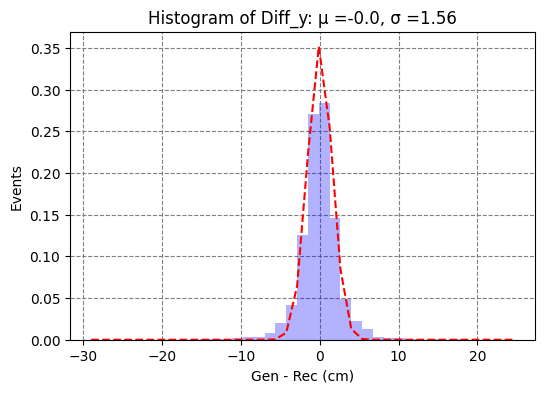

In [47]:
#set x-axis limits so that histogram is centered
xmin = 0
xmax = np.ceil(mu)*2

#plot histogram 
ax = df_diff_n.plot('Diff_y',#,+diff, 
        kind='hist', 
        bins=custom_bins,
        density=False,
        weights = bin_weights,
        title = 'Histogram of Diff_'+diff+': μ ='+str(np.round(mu,2))+', σ ='+str(np.round(std,2)),
        ylabel = 'Events', 
        xlabel='Gen - Rec (cm)',
        rot = 0,
        color='blue',
        legend = None,
        figsize=(6, 4),
        alpha=0.3)

#plot gaussian fit
ax.plot(custom_bins, g*g_weight, color='red', linestyle='dashed')

#set plot parameters
ax.set_axisbelow(True)
#ax.set_xlim([xmin, xmax]) #uncomment for centered histogram
ax.yaxis.grid(color='gray', linestyle='dashed')
ax.xaxis.grid(color='gray', linestyle='dashed')
#ax.get_figure().savefig('energy-distribution-'+root_file+'_noise-'+str(noise)+'_signal'+str(cluster_n)+'.png', bbox_inches = 'tight')

In [104]:
df_diff_mean = df_diff.groupby('event_n')
df_diff_mean = df_diff_mean.mean()
df_diff_mean

,Diff_x,Diff_y
event_n,,
0,-0.092824,-0.056334
1,0.097610,-0.001666
2,-0.051294,0.032562
3,-0.066634,0.043410
4,0.057861,-0.055838
...,...,...
995,0.022971,0.023277
996,-0.102074,0.063231
997,0.064211,-0.062159


In [105]:
#set up histogram bining for one event
diff = 'y'
bin_n = 120
bin_width = (np.ceil(df_diff_mean['Diff_'+diff].max()) - np.floor(df_diff_mean['Diff_'+diff].min()))/bin_n
custom_bins = np.arange(np.floor(df_diff_mean['Diff_'+diff].min()), np.ceil(df_diff_mean['Diff_'+diff].max()), bin_width)

custom_bins

array([-1.00000000e+00, -9.83333333e-01, -9.66666667e-01, -9.50000000e-01,
       -9.33333333e-01, -9.16666667e-01, -9.00000000e-01, -8.83333333e-01,
       -8.66666667e-01, -8.50000000e-01, -8.33333333e-01, -8.16666667e-01,
       -8.00000000e-01, -7.83333333e-01, -7.66666667e-01, -7.50000000e-01,
       -7.33333333e-01, -7.16666667e-01, -7.00000000e-01, -6.83333333e-01,
       -6.66666667e-01, -6.50000000e-01, -6.33333333e-01, -6.16666667e-01,
       -6.00000000e-01, -5.83333333e-01, -5.66666667e-01, -5.50000000e-01,
       -5.33333333e-01, -5.16666667e-01, -5.00000000e-01, -4.83333333e-01,
       -4.66666667e-01, -4.50000000e-01, -4.33333333e-01, -4.16666667e-01,
       -4.00000000e-01, -3.83333333e-01, -3.66666667e-01, -3.50000000e-01,
       -3.33333333e-01, -3.16666667e-01, -3.00000000e-01, -2.83333333e-01,
       -2.66666667e-01, -2.50000000e-01, -2.33333333e-01, -2.16666667e-01,
       -2.00000000e-01, -1.83333333e-01, -1.66666667e-01, -1.50000000e-01,
       -1.33333333e-01, -

In [106]:
#custom binning for better fit
bin_min = -0.10
bin_max = 0.10
#bin_n = 80
#bin_width = (bin_max - bin_min)/bin_n
#custom_bins = np.arange(bin_min, bin_max, bin_width)

df_diff_fit = df_diff_mean[(df_diff_mean['Diff_'+diff]>=bin_min) & (df_diff_mean['Diff_'+diff]<=bin_max)]

In [107]:
#set up bins weights so that summing the bars up gives 1
bin_weights = np.ones_like(df_diff_mean['Diff_'+diff]) / len(df_diff_mean['Diff_'+diff])

In [108]:
#fit data to gaussian distribution
mu, std = scipy.stats.norm.fit(df_diff_fit['Diff_'+diff])
g = scipy.stats.norm.pdf(custom_bins, mu, std)

In [109]:
#get fit weight correction for weighted/density histogram
sums_w, bins_w = np.histogram(df_diff_mean['Diff_'+diff], custom_bins, weights = bin_weights)
sums_d, bins_d = np.histogram(df_diff_mean['Diff_'+diff], custom_bins, density = True)
g_weight = np.amax(sums_w)/np.amax(sums_d)

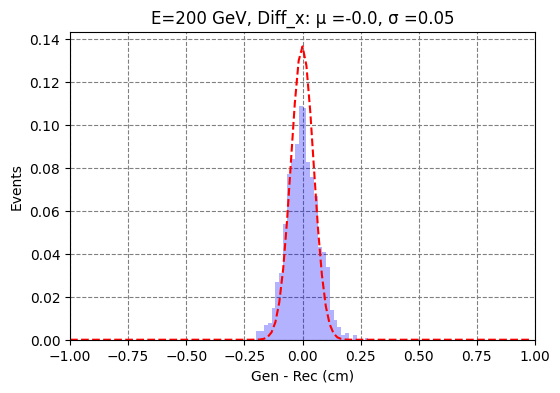

In [110]:
### set x-axis limits so that histogram is centered
xmin = -1
xmax = 1

#plot histogram 
ax = df_diff_mean.plot('Diff_x',#+diff, 
        kind='hist', 
        bins=custom_bins,
        density=False,
        weights = bin_weights,
        title = 'E='+str(energy)+' GeV, Diff_'+'x'+': μ ='+str(np.round(mu,2))+', σ ='+str(np.round(std,2)),
        ylabel = 'Events', 
        xlabel='Gen - Rec (cm)',
        rot = 0,
        color='blue',
        legend = None,
        figsize=(6, 4),
        alpha=0.3)

#plot gaussian fit
ax.plot(custom_bins, g*g_weight, color='red', linestyle='dashed')

#set plot parameters
ax.set_axisbelow(True)
ax.set_xlim([xmin, xmax]) #uncomment for centered histogram
ax.yaxis.grid(color='gray', linestyle='dashed')
ax.xaxis.grid(color='gray', linestyle='dashed')
ax.get_figure().savefig('position_distribution_E'+str(energy)+'_diffx_new.png', bbox_inches = 'tight')